**TASK 1**

Problem 1

In [1]:
import tensorflow as tf
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import sys

# Print package versions
print("--- Environment Versions ---")
print(f"Python version: {sys.version.split()[0]}")
print(f"TensorFlow version: {tf.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

# GPU Verification
print("\n--- GPU Verification ---")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU Detected: {gpus}")
else:
    print("No GPU Detected. Running on CPU.")

# Setting Random Seeds for Reproducibility
seed_value = 42

# 1. Set Python built-in random seed
random.seed(seed_value)

# 2. Set NumPy random seed
np.random.seed(seed_value)

# 3. Set TensorFlow random seed
tf.random.set_seed(seed_value)

print("\nAll random seeds set to 42 for reproducibility.")

--- Environment Versions ---
Python version: 3.12.13
TensorFlow version: 2.19.0
Matplotlib version: 3.10.0
NumPy version: 2.0.2
Pandas version: 2.2.2

--- GPU Verification ---
GPU Detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

All random seeds set to 42 for reproducibility.


CPU training is much slower for Deep Learning because CPUs are designed for sequential processing with a few highly capable cores. GPUs have thousands of smaller cores designed specifically for massive parallel processing. Convolutional Neural Networks rely on massive matrix multiplications, which GPUs can compute simultaneously, vastly speeding up training.

Seed Explanation:

random.seed: Controls standard Python random operations.

np.random.seed: Controls NumPy array random initializations.

tf.random.set_seed: Controls TensorFlow graph-level random generation (e.g., weight initialization).

Problem 2

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 24s 0us/step


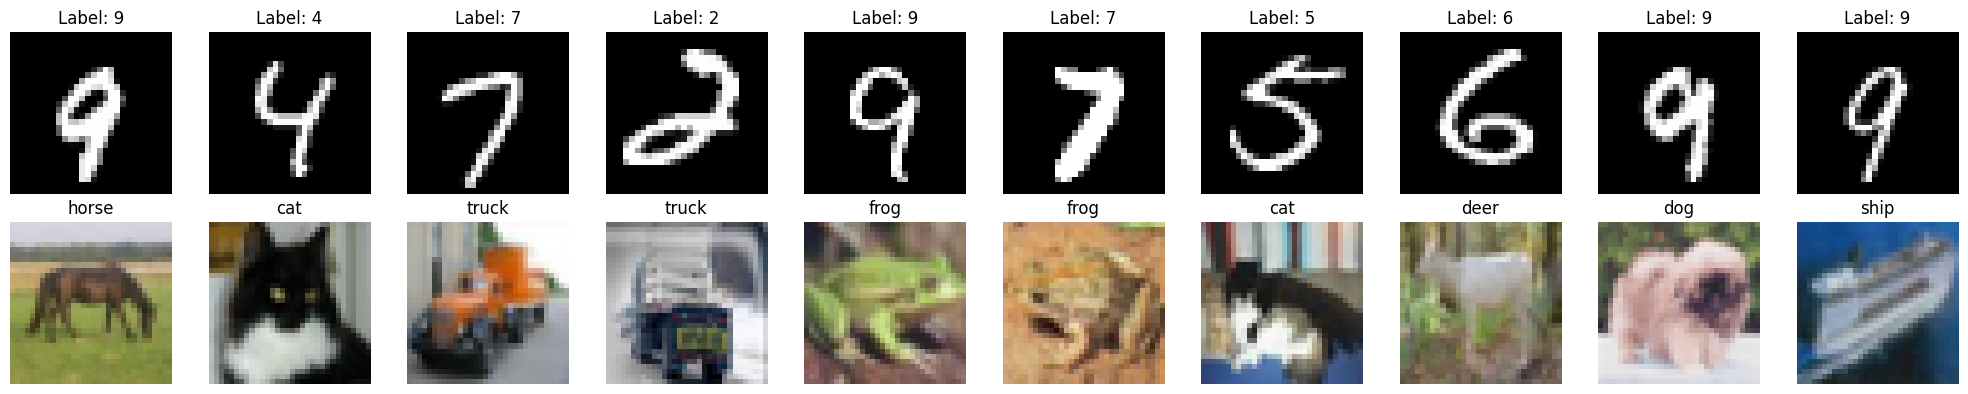

In [2]:
# Load Datasets
(mnist_train_images, mnist_train_labels), (mnist_test_images, mnist_test_labels) = tf.keras.datasets.mnist.load_data()
(cifar_train_images, cifar_train_labels), (cifar_test_images, cifar_test_labels) = tf.keras.datasets.cifar10.load_data()

# CIFAR-10 Class Names mapping
cifar_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

fig, axes = plt.subplots(2, 10, figsize=(20, 4))

# Top Row: MNIST
for i in range(10):
    idx = random.randint(0, len(mnist_train_images) - 1)
    axes[0, i].imshow(mnist_train_images[idx], cmap='gray')
    axes[0, i].set_title(f"Label: {mnist_train_labels[idx]}")
    axes[0, i].axis('off')

# Bottom Row: CIFAR-10
for i in range(10):
    idx = random.randint(0, len(cifar_train_images) - 1)
    axes[1, i].imshow(cifar_train_images[idx])
    axes[1, i].set_title(f"{cifar_classes[cifar_train_labels[idx][0]]}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('dataset_samples.png') # This saves to Colab's file explorer
plt.show()

Write your shape/dtype/range observations here:

(a) Shapes:

MNIST: Training arrays are (60000, 28, 28) for images and (60000,) for labels. Test: (10000, 28, 28) and (10000,).

CIFAR-10: Training arrays are (50000, 32, 32, 3) for images and (50000, 1) for labels. Test: (10000, 32, 32, 3) and (10000, 1).

(b) Data Type & Value Range: The raw pixel data type is uint8. The value range is 0 to 255.

(c) MNIST Class Balance: There are 60,000 training samples divided across 10 classes. The distribution is roughly ~6,000 samples per class, meaning the dataset is highly balanced.

Problem 3

In [3]:
def preprocess_pipeline(images, labels, is_mnist=False):
    print(f"--- Before Preprocessing ({'MNIST' if is_mnist else 'CIFAR'} ) ---")
    print(f"Images shape: {images.shape}, Labels shape: {labels.shape}")
    print(f"Images dtype: {images.dtype}, Min val: {images.min()}, Max val: {images.max()}")

    # (a) Normalise pixel values to [0.0, 1.0] and ensure float32
    processed_images = images.astype('float32') / 255.0

    # (b) Reshape MNIST images to add channel dimension
    if is_mnist:
        processed_images = np.expand_dims(processed_images, axis=-1)

    # (c) One-hot encode labels
    processed_labels = tf.keras.utils.to_categorical(labels, num_classes=10)

    print(f"--- After Preprocessing ({'MNIST' if is_mnist else 'CIFAR'} ) ---")
    print(f"Images shape: {processed_images.shape}, Labels shape: {processed_labels.shape}")
    print(f"Images dtype: {processed_images.dtype}, Min val: {processed_images.min()}, Max val: {processed_images.max()}\n")

    return processed_images, processed_labels

x_train_mnist, y_train_mnist = preprocess_pipeline(mnist_train_images, mnist_train_labels, is_mnist=True)
x_train_cifar, y_train_cifar = preprocess_pipeline(cifar_train_images, cifar_train_labels, is_mnist=False)

--- Before Preprocessing (MNIST ) ---
Images shape: (60000, 28, 28), Labels shape: (60000,)
Images dtype: uint8, Min val: 0, Max val: 255
--- After Preprocessing (MNIST ) ---
Images shape: (60000, 28, 28, 1), Labels shape: (60000, 10)
Images dtype: float32, Min val: 0.0, Max val: 1.0

--- Before Preprocessing (CIFAR ) ---
Images shape: (50000, 32, 32, 3), Labels shape: (50000, 1)
Images dtype: uint8, Min val: 0, Max val: 255
--- After Preprocessing (CIFAR ) ---
Images shape: (50000, 32, 32, 3), Labels shape: (50000, 10)
Images dtype: float32, Min val: 0.0, Max val: 1.0



Problem 4

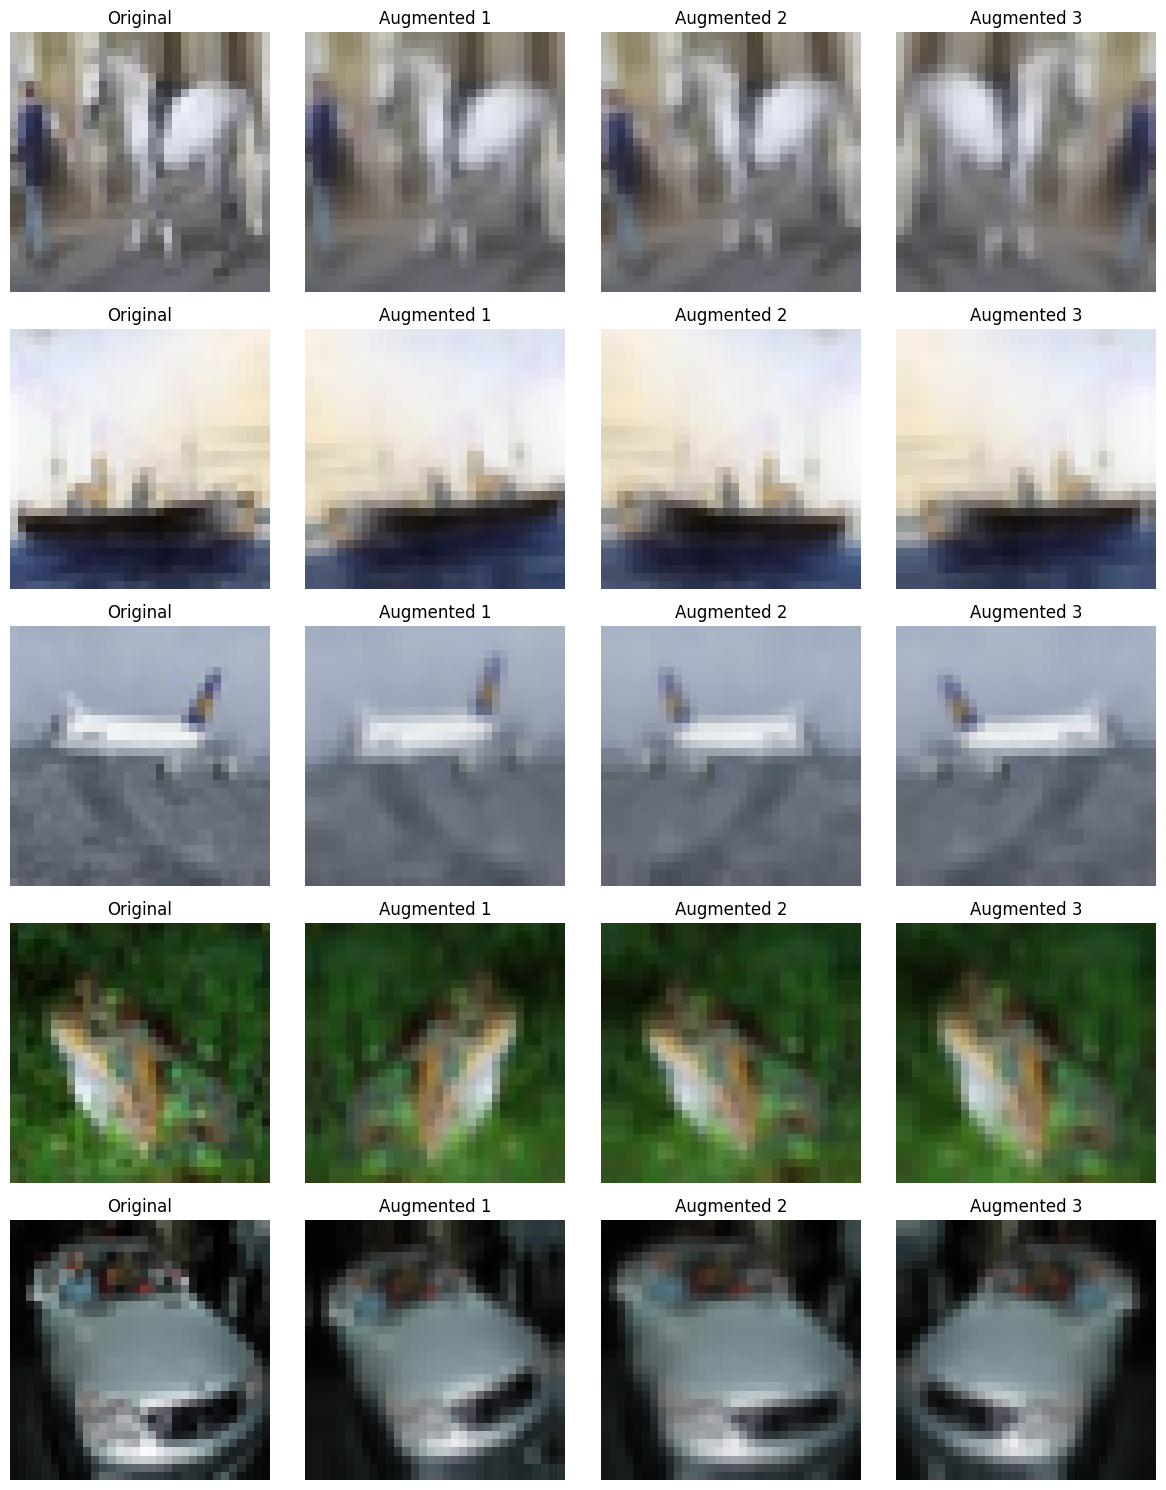

In [4]:
# Define the augmentation pipeline
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(factor=0.0277), # ~10 degrees
    tf.keras.layers.RandomZoom(height_factor=(-0.1, 0.1), width_factor=(-0.1, 0.1))
])

# Select 5 random CIFAR-10 images
sample_indices = np.random.choice(len(x_train_cifar), 5, replace=False)
sample_images = x_train_cifar[sample_indices]

# Plot 5 originals x 4 versions
fig, axes = plt.subplots(5, 4, figsize=(12, 15))

for i, img in enumerate(sample_images):
    axes[i, 0].imshow(img)
    axes[i, 0].set_title("Original")
    axes[i, 0].axis('off')

    for j in range(1, 4):
        aug_img = data_augmentation(np.expand_dims(img, 0), training=True)[0]
        axes[i, j].imshow(aug_img.numpy().clip(0, 1))
        axes[i, j].set_title(f"Augmented {j}")
        axes[i, j].axis('off')

plt.tight_layout()
plt.savefig('augmentation_demo.png')
plt.show()

Why must augmentation be applied only to the training set and never to the validation or
test set?

Augmentation artificially expands training data diversity to prevent overfitting. If applied to validation/test sets, we corrupt the real-world data distribution we use to evaluate the model, rendering our accuracy metrics invalid.

Answer Q1: The channel dimension (C in N, H, W, C) represents the depth of the image data (color channels). In a greyscale image (MNIST), C = 1 (intensity from black to white). In an RGB image (CIFAR-10), C = 3 (Red, Green, Blue intensities).

Answer Q2: Two techniques to avoid Out of Memory (OOM) errors on 1024x1024 images:

Data Generators (tf.data.Dataset): Streams data continuously in small batches from storage during training rather than loading the whole dataset into RAM at once.

Patching/Tiling: Cropping the large images into smaller grids (e.g., 256x256). This lowers the spatial dimensions fed into the CNN, reducing memory needed for intermediate activation maps.

Answer Q3: This is data leakage. The test set simulates unseen future data. You cannot compute an aggregate mean/std of "future" data. To accurately evaluate the model, you must scale the test set using the exact mean and standard deviation computed strictly from the training set.

**TASK 2**

Problem 1

In [5]:
import numpy as np

def conv2d(image, kernel, stride=1, padding=0):
    # Add zero padding to the image if specified
    if padding > 0:
        image = np.pad(image, pad_width=padding, mode='constant', constant_values=0)

    img_h, img_w = image.shape
    kern_h, kern_w = kernel.shape

    # Calculate output dimensions: floor((Input - Kernel + 2*Padding) / Stride) + 1
    out_h = (img_h - kern_h) // stride + 1
    out_w = (img_w - kern_w) // stride + 1

    output = np.zeros((out_h, out_w))

    # Slide the kernel across the image
    for y in range(0, out_h):
        for x in range(0, out_w):
            # Extract the current patch (window)
            y_start = y * stride
            y_end = y_start + kern_h
            x_start = x * stride
            x_end = x_start + kern_w

            patch = image[y_start:y_end, x_start:x_end]

            # Element-wise multiply and sum [cite: 129]
            output[y, x] = np.sum(patch * kernel)

    return output

# Test with Sobel-X kernel on the provided 5x5 image [cite: 125, 126]
test_image = np.array([
    [3, 1, 0, 2, 4],
    [1, 5, 3, 2, 1],
    [0, 2, 6, 4, 3],
    [2, 3, 1, 5, 2],
    [1, 0, 2, 3, 4]
])
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])

result = conv2d(test_image, sobel_x, stride=1, padding=0)
print("Numerical output of conv2d function:\n", result)
print("\nOutput shape:", result.shape)

Numerical output of conv2d function:
 [[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]

Output shape: (3, 3)


Problem 2

Use the formula: $Output = \lfloor \frac{Input - Kernel + 2 \times Padding}{Stride} \rfloor + 1$.(a) Input 28x28, K=5, P=0, S=1: $\lfloor (28 - 5 + 0)/1 \rfloor + 1 = 24$. Output: 24x24.(b) Input 28x28, K=3, P=1, S=1: $\lfloor (28 - 3 + 2)/1 \rfloor + 1 = 28$. Output: 28x28.(c) Input 32x32, K=3, P=0, S=2: $\lfloor (32 - 3 + 0)/2 \rfloor + 1 = \lfloor 14.5 \rfloor + 1 = 15$. Output: 15x15.(d) Two layers: * Layer 1 (Input 32, K3, P1, S1): $\lfloor (32-3+2)/1 \rfloor + 1 = 32$.Layer 2 (Input 32, K3, P0, S1): $\lfloor (32-3+0)/1 \rfloor + 1 = 30$.Final Size: 30x30.

Problem 3

In [6]:
from tensorflow.keras import layers, models

def build_lenet5():
    model = models.Sequential([
        # C1: Conv (6 filters, 5x5, valid) + Tanh [cite: 146]
        layers.Conv2D(6, (5, 5), activation='tanh', input_shape=(28, 28, 1), padding='valid'),
        # S2: AvgPool (2x2, stride 2) [cite: 151]
        layers.AveragePooling2D(pool_size=(2, 2), strides=2),
        # C3: Conv (16 filters, 5x5, valid) + Tanh [cite: 146]
        layers.Conv2D(16, (5, 5), activation='tanh', padding='valid'),
        # S4: AvgPool (2x2, stride 2) [cite: 151]
        layers.AveragePooling2D(pool_size=(2, 2), strides=2),
        # Flatten for Dense layers [cite: 152]
        layers.Flatten(),
        # C5: Dense (120) + Tanh [cite: 153]
        layers.Dense(120, activation='tanh'),
        # F6: Dense (84) + Tanh [cite: 147]
        layers.Dense(84, activation='tanh'),
        # Output: Dense (10) + Softmax [cite: 149]
        layers.Dense(10, activation='softmax')
    ])
    return model

lenet = build_lenet5()
lenet.summary() # Verify total parameters = 44,426 [cite: 150]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

(b) Parameter Calculation (1st Conv Layer):Formula: $(Kernel\_H \times Kernel\_W \times C_{in} + 1) \times C_{out}$.Values: $(5 \times 5 \times 1 + 1) \times 6 = 26 \times 6 = \mathbf{156}$ parameters.(c) Average vs. Max Pooling: LeNet-5 used Average Pooling to provide local translation invariance by smoothing the signal. Today, Max Pooling is more common because it better preserves dominant features (like edges and high activations) and introduces a stronger form of non-linearity, which generally leads to better performance in modern deep networks.

Problem 4

In [7]:
# Design Rationale:
# 1. 3 Conv blocks used to extract hierarchical features (edges -> textures -> shapes)[cite: 165].
# 2. BatchNorm stabilizes training; ReLU provides non-linearity[cite: 180, 181].
# 3. Dropout (0.5) is used in the head to prevent overfitting on CIFAR-10's complex classes[cite: 166].
# 4. Flatten connects the 3D feature maps to the final 1D classification head[cite: 167].

def build_custom_cifar_cnn():
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), padding='same', input_shape=(32, 32, 3)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        # Block 2
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        # Block 3
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        # Classification Head
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    return model

custom_model = build_custom_cifar_cnn()
custom_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,258 (2.37 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)


Establishing your intent to complete Task 2: Building a CNN from Scratch in Google Colab, here is the structured solution. This task focuses on manual convolution implementation, architectural math, and building your first models.

Task 2 Setup
Ensure you have already run the seed initialization from Task 1 to maintain reproducibility (Random Seed = 42).
+1

Cell 1 (Code): Manual 2D Convolution
This cell implements a manual convolution function using only NumPy as required.

Python
import numpy as np

def conv2d(image, kernel, stride=1, padding=0):
    # Add zero padding to the image if specified
    if padding > 0:
        image = np.pad(image, pad_width=padding, mode='constant', constant_values=0)
    
    img_h, img_w = image.shape
    kern_h, kern_w = kernel.shape
    
    # Calculate output dimensions: floor((Input - Kernel + 2*Padding) / Stride) + 1
    out_h = (img_h - kern_h) // stride + 1
    out_w = (img_w - kern_w) // stride + 1
    
    output = np.zeros((out_h, out_w))
    
    # Slide the kernel across the image
    for y in range(0, out_h):
        for x in range(0, out_w):
            # Extract the current patch (window)
            y_start = y * stride
            y_end = y_start + kern_h
            x_start = x * stride
            x_end = x_start + kern_w
            
            patch = image[y_start:y_end, x_start:x_end]
            
            # Element-wise multiply and sum [cite: 129]
            output[y, x] = np.sum(patch * kernel)
            
    return output

# Test with Sobel-X kernel on the provided 5x5 image [cite: 125, 126]
test_image = np.array([
    [3, 1, 0, 2, 4],
    [1, 5, 3, 2, 1],
    [0, 2, 6, 4, 3],
    [2, 3, 1, 5, 2],
    [1, 0, 2, 3, 4]
])
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])

result = conv2d(test_image, sobel_x, stride=1, padding=0)
print("Numerical output of conv2d function:\n", result)
print("\nOutput shape:", result.shape)
Cell 2 (Text/Markdown): Problem 2 Output Size Derivation
Use the formula: Output=⌊
Stride
Input−Kernel+2×Padding
​
 ⌋+1.
+2

(a) Input 28x28, K=5, P=0, S=1: ⌊(28−5+0)/1⌋+1=24. Output: 24x24.

(b) Input 28x28, K=3, P=1, S=1: ⌊(28−3+2)/1⌋+1=28. Output: 28x28.

(c) Input 32x32, K=3, P=0, S=2: ⌊(32−3+0)/2⌋+1=⌊14.5⌋+1=15. Output: 15x15.

(d) Two layers: * Layer 1 (Input 32, K3, P1, S1): ⌊(32−3+2)/1⌋+1=32.

Layer 2 (Input 32, K3, P0, S1): ⌊(32−3+0)/1⌋+1=30.

Final Size: 30x30.

Cell 3 (Code): Implement LeNet-5
This builds the 1998 LeNet-5 architecture exactly as described.

Python
from tensorflow.keras import layers, models

def build_lenet5():
    model = models.Sequential([
        # C1: Conv (6 filters, 5x5, valid) + Tanh [cite: 146]
        layers.Conv2D(6, (5, 5), activation='tanh', input_shape=(28, 28, 1), padding='valid'),
        # S2: AvgPool (2x2, stride 2) [cite: 151]
        layers.AveragePooling2D(pool_size=(2, 2), strides=2),
        # C3: Conv (16 filters, 5x5, valid) + Tanh [cite: 146]
        layers.Conv2D(16, (5, 5), activation='tanh', padding='valid'),
        # S4: AvgPool (2x2, stride 2) [cite: 151]
        layers.AveragePooling2D(pool_size=(2, 2), strides=2),
        # Flatten for Dense layers [cite: 152]
        layers.Flatten(),
        # C5: Dense (120) + Tanh [cite: 153]
        layers.Dense(120, activation='tanh'),
        # F6: Dense (84) + Tanh [cite: 147]
        layers.Dense(84, activation='tanh'),
        # Output: Dense (10) + Softmax [cite: 149]
        layers.Dense(10, activation='softmax')
    ])
    return model

lenet = build_lenet5()
lenet.summary() # Verify total parameters = 44,426 [cite: 150]
Cell 4 (Text/Markdown): LeNet-5 Calculation & Logic
(b) Parameter Calculation (1st Conv Layer):

Formula: (Kernel_H×Kernel_W×C
in
​
 +1)×C
out
​
 .
+1

Values: (5×5×1+1)×6=26×6=156 parameters.


(c) Average vs. Max Pooling: LeNet-5 used Average Pooling to provide local translation invariance by smoothing the signal. Today, Max Pooling is more common because it better preserves dominant features (like edges and high activations) and introduces a stronger form of non-linearity, which generally leads to better performance in modern deep networks.

Cell 5 (Code): Custom CNN for CIFAR-10
Building a custom architecture within the 200k–2M parameter range.
+1

Python
# Design Rationale:
# 1. 3 Conv blocks used to extract hierarchical features (edges -> textures -> shapes)[cite: 165].
# 2. BatchNorm stabilizes training; ReLU provides non-linearity[cite: 180, 181].
# 3. Dropout (0.5) is used in the head to prevent overfitting on CIFAR-10's complex classes[cite: 166].
# 4. Flatten connects the 3D feature maps to the final 1D classification head[cite: 167].

def build_custom_cifar_cnn():
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), padding='same', input_shape=(32, 32, 3)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        
        # Block 2
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        
        # Block 3
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        
        # Classification Head
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    return model

custom_model = build_custom_cifar_cnn()
custom_model.summary()
Cell 6 (Text/Markdown): Task 2 Analysis Questions
Answer Q1 (Efficiency of Kernels):


Two stacked 3x3 layers: (3×3×C+1)×C+(3×3×C+1)×C≈18C
2
  params.

One 5x5 layer: (5×5×C+1)×C≈25C
2
  params.

Numerical Proof: For C=32 filters, stacked 3x3 uses ≈18,432 params, while 5x5 uses ≈25,600 params. The smaller kernels are more efficient.


Advantage: Smaller kernels allow for more non-linearities (two ReLUs instead of one), increasing the model's representational power.

Answer Q2 (Batch Normalization):


Role: It normalizes layer inputs to have a mean of 0 and variance of 1, reducing "internal covariate shift".


Placement: Usually placed before the activation function (though researchers debate this, the original paper suggests before) to ensure the non-linearity receives a standardized input distribution.


Benefits: Faster convergence (higher learning rates possible) and it acts as a mild regularizer.

Answer Q3 (GAP vs. Flatten):


Geometric Role: GlobalAveragePooling (GAP) takes the average of each feature map across its entire spatial width and height, reducing a (H,W,C) tensor to (1,1,C).

Change: If replaced with Flatten, the parameter count in the following Dense layer would skyrocket because it multiplies all spatial pixels (H×W×C) by the units, whereas GAP only uses 1×1×C. However, Flatten preserves more precise spatial information that GAP might "average out".

**TASK 3**

In [8]:
import tensorflow as tf
import numpy as np

# 1. Load the raw datasets
(mnist_train_images, mnist_train_labels), (mnist_test_images, mnist_test_labels) = tf.keras.datasets.mnist.load_data()
(cifar_train_images, cifar_train_labels), (cifar_test_images, cifar_test_labels) = tf.keras.datasets.cifar10.load_data()

# 2. Preprocess MNIST (Normalise, Reshape to add channel, One-hot encode labels)
x_train_mnist = mnist_train_images.astype('float32') / 255.0
x_train_mnist = np.expand_dims(x_train_mnist, axis=-1)
x_test_mnist = mnist_test_images.astype('float32') / 255.0
x_test_mnist = np.expand_dims(x_test_mnist, axis=-1)

y_train_mnist = tf.keras.utils.to_categorical(mnist_train_labels, 10)
y_test_mnist = tf.keras.utils.to_categorical(mnist_test_labels, 10)

# 3. Preprocess CIFAR-10 (Normalise, One-hot encode labels)
x_train_cifar = cifar_train_images.astype('float32') / 255.0
x_test_cifar = cifar_test_images.astype('float32') / 255.0

y_train_cifar = tf.keras.utils.to_categorical(cifar_train_labels, 10)
y_test_cifar = tf.keras.utils.to_categorical(cifar_test_labels, 10)

print("Data variables defined successfully:")
print(f"MNIST Train Shape: {x_train_mnist.shape}")
print(f"CIFAR Train Shape: {x_train_cifar.shape}")

Data variables defined successfully:
MNIST Train Shape: (60000, 28, 28, 1)
CIFAR Train Shape: (50000, 32, 32, 3)


In [9]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Set seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

def build_lenet5():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28, 1)),
        tf.keras.layers.Conv2D(6, kernel_size=(5, 5), activation='tanh', padding='valid'),
        tf.keras.layers.AveragePooling2D(pool_size=(2, 2), strides=2),
        tf.keras.layers.Conv2D(16, kernel_size=(5, 5), activation='tanh', padding='valid'),
        tf.keras.layers.AveragePooling2D(pool_size=(2, 2), strides=2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(120, activation='tanh'),
        tf.keras.layers.Dense(84, activation='tanh'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

def build_custom_cifar_cnn():
    # Example compliant with Task 2: 3 blocks, BatchNorm, Dropout, 200k-2M params
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(32, 32, 3)),
        # Block 1
        tf.keras.layers.Conv2D(64, (3, 3), padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        # Block 2
        tf.keras.layers.Conv2D(128, (3, 3), padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        # Block 3
        tf.keras.layers.Conv2D(256, (3, 3), padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7726 - loss: 0.8962 - val_accuracy: 0.9050 - val_loss: 0.3704
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8944 - loss: 0.3798 - val_accuracy: 0.9238 - val_loss: 0.2764
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9100 - loss: 0.3107 - val_accuracy: 0.9330 - val_loss: 0.2348
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9216 - loss: 0.2697 - val_accuracy: 0.9400 - val_loss: 0.2064
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9295 - loss: 0.2387 - val_accuracy: 0.9478 - val_loss: 0.1842
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9365 - loss: 0.2135 - val_accuracy: 0.9523 - val_loss: 0.1658
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9426 - loss: 0.1923 - val_accuracy: 0.9570 - val_loss: 0.1504
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9485 - loss: 0.1743 - val_accuracy: 0.

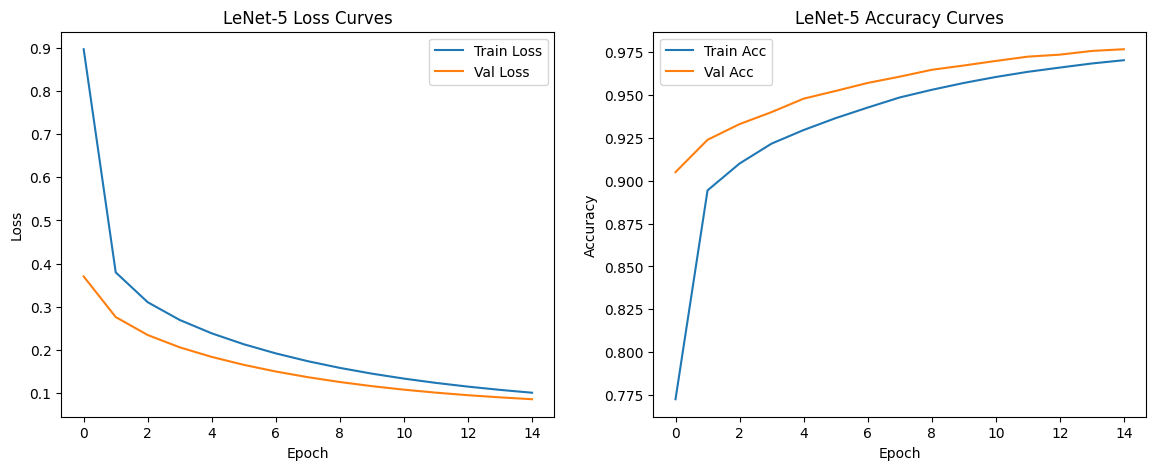

Final Test Accuracy: 0.9726


In [10]:
# (a) & (b) Training and Plotting
model_p1 = build_lenet5()
model_p1.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

history_p1 = model_p1.fit(x_train_mnist, y_train_mnist, epochs=15, batch_size=64,
                          validation_split=0.1, verbose=1)

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history_p1.history['loss'], label='Train Loss')
ax1.plot(history_p1.history['val_loss'], label='Val Loss')
ax1.set_title('LeNet-5 Loss Curves')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend()

ax2.plot(history_p1.history['accuracy'], label='Train Acc')
ax2.plot(history_p1.history['val_accuracy'], label='Val Acc')
ax2.set_title('LeNet-5 Accuracy Curves')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.legend()

plt.savefig('lenet_sgd_curves.png')
plt.show()

# (d) Final Test Accuracy
test_loss, test_acc = model_p1.evaluate(x_test_mnist, y_test_mnist, verbose=0)
print(f"Final Test Accuracy: {test_acc:.4f}")

Problem 2

--- Currently Training with Optimiser: SGD ---
Final Val Accuracy for SGD: 0.9760
--- Currently Training with Optimiser: SGD_with_Momentum ---
Final Val Accuracy for SGD_with_Momentum: 0.9898
--- Currently Training with Optimiser: Adam ---
Final Val Accuracy for Adam: 0.9853


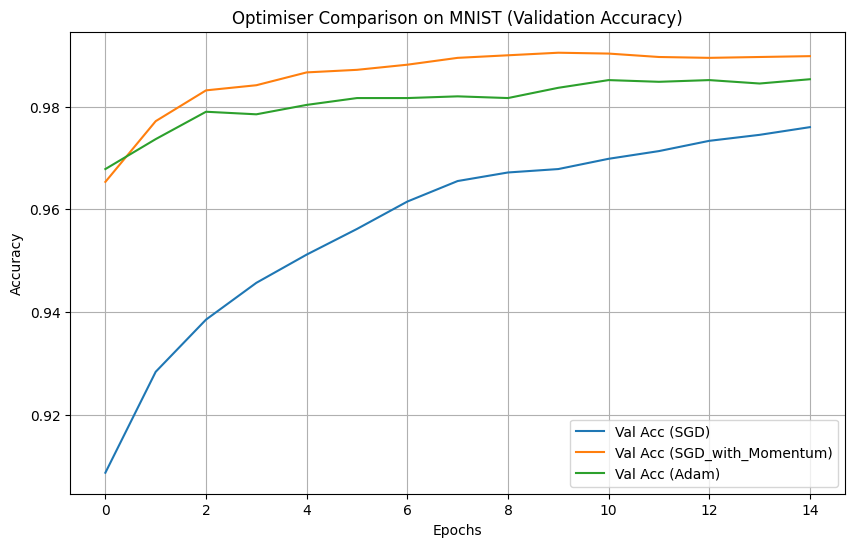

In [11]:
# (a, b, c) Defining the three optimisers as per the assignment
optimisers_to_test = {
    'SGD': tf.keras.optimizers.SGD(learning_rate=0.01),
    'SGD_with_Momentum': tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'Adam': tf.keras.optimizers.Adam(learning_rate=0.001)
}

# Create a figure for the validation accuracy plot
plt.figure(figsize=(10, 6))

# Store results for analysis
for name, opt in optimisers_to_test.items():
    print(f"--- Currently Training with Optimiser: {name} ---")

    # IMPORTANT: We build a fresh LeNet-5 model every time so weights are reset
    model = build_lenet5()

    model.compile(optimizer=opt,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # Train for 15 epochs with 10% validation split
    history = model.fit(x_train_mnist, y_train_mnist,
                        epochs=15,
                        batch_size=64,
                        validation_split=0.1,
                        verbose=0) # verbose=0 keeps the output clean

    # Plot validation accuracy for this optimiser
    plt.plot(history.history['val_accuracy'], label=f'Val Acc ({name})')
    print(f"Final Val Accuracy for {name}: {history.history['val_accuracy'][-1]:.4f}")

# Finalizing the plot as required by instructions
plt.title('Optimiser Comparison on MNIST (Validation Accuracy)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('optimiser_comparison.png') # This saves the file to Colab's explorer
plt.show()

Problem 3

In [12]:
import pandas as pd

lrs = [0.1, 0.01, 0.001]
batch_sizes = [32, 128]
grid_results = []

for lr in lrs:
    row_results = []
    for bs in batch_sizes:
        print(f"Testing LR={lr}, Batch Size={bs}...")

        # Reset weights for every combination [cite: 198]
        model = build_custom_cifar_cnn()
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                      loss='categorical_crossentropy', metrics=['accuracy'])

        # Train for 10 epochs
        history = model.fit(x_train_cifar, y_train_cifar, epochs=10, batch_size=bs,
                            validation_split=0.1, verbose=0)

        row_results.append(max(history.history['val_accuracy']))
    grid_results.append(row_results)

# Present findings in a 3x2 table [cite: 196]
df_grid = pd.DataFrame(grid_results, index=lrs, columns=batch_sizes)
print("\n3x2 Results Table (Final Validation Accuracy):")
print(df_grid)

Testing LR=0.1, Batch Size=32...
Testing LR=0.1, Batch Size=128...
Testing LR=0.01, Batch Size=32...
Testing LR=0.01, Batch Size=128...
Testing LR=0.001, Batch Size=32...
Testing LR=0.001, Batch Size=128...

3x2 Results Table (Final Validation Accuracy):
          32      128
0.100  0.3334  0.4728
0.010  0.7518  0.7330
0.001  0.7096  0.6836


Problem 4

In [13]:
# Helper to build variants
def build_reg_variant(use_dropout=False, use_bn=False):
    model = tf.keras.Sequential()
    # Adding simplified blocks for testing
    for filters in [32, 64]:
        model.add(tf.keras.layers.Conv2D(filters, (3, 3), padding='same', input_shape=(32,32,3)))
        if use_bn: model.add(tf.keras.layers.BatchNormalization()) #
        model.add(tf.keras.layers.Activation('relu'))
        model.add(tf.keras.layers.MaxPooling2D((2, 2)))
        if use_dropout: model.add(tf.keras.layers.Dropout(0.3)) #

    model.add(tf.keras.layers.Flatten())
    if use_dropout: model.add(tf.keras.layers.Dropout(0.5)) #
    model.add(tf.keras.layers.Dense(10, activation='softmax'))
    return model

variants = {"None": (0,0), "Dropout Only": (1,0), "BN Only": (0,1), "Both": (1,1)}
reg_stats = []

for name, (d, b) in variants.items():
    print(f"Training Variant: {name}")
    m = build_reg_variant(use_dropout=d, use_bn=b)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(x_train_cifar, y_train_cifar, epochs=20, batch_size=128, validation_split=0.1, verbose=0)

    # Calculate Train-Val Gap [cite: 200]
    gap = h.history['accuracy'][-1] - h.history['val_accuracy'][-1]
    reg_stats.append({"Variant": name, "Train-Val Gap": gap})

print("\nRegularisation Comparison Table:")
print(pd.DataFrame(reg_stats))

Training Variant: None


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Variant: Dropout Only
Training Variant: BN Only
Training Variant: Both

Regularisation Comparison Table:
        Variant  Train-Val Gap
0          None       0.093622
1  Dropout Only      -0.045889
2       BN Only       0.177956
3          Both      -0.036378


Problem 5


Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 29: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.


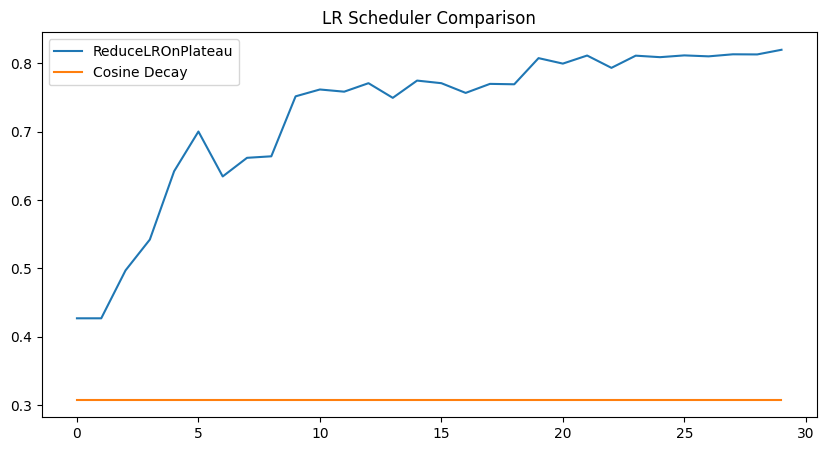

In [14]:
# (a) ReduceLROnPlateau
lr_reducer = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
model_a = build_custom_cifar_cnn()
model_a.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
history_a = model_a.fit(x_train_cifar, y_train_cifar, epochs=30, validation_split=0.1, callbacks=[lr_reducer], verbose=0)

# (b) Cosine Annealing
lr_sched = tf.keras.optimizers.schedules.CosineDecay(0.001, decay_steps=30)
model_b = build_custom_cifar_cnn()
model_b.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr_sched), loss='categorical_crossentropy', metrics=['accuracy'])
history_b = model_b.fit(x_train_cifar, y_train_cifar, epochs=30, validation_split=0.1, verbose=0)

# Plot accuracy side-by-side [cite: 204]
plt.figure(figsize=(10, 5))
plt.plot(history_a.history['val_accuracy'], label='ReduceLROnPlateau')
plt.plot(history_b.history['val_accuracy'], label='Cosine Decay')
plt.title('LR Scheduler Comparison')
plt.legend()
plt.savefig('lr_schedule_comparison.png') # Required filename [cite: 204]
plt.show()

**TASK 4**

Problem 1

In [18]:
# If you used the code I gave you for Task 3 Problem 4, run this:
best_cifar_model = m

# OR if you just named it 'model' in Task 2, run this:
# best_cifar_model = model

# Verify it worked
print("Model linked successfully. Summary:")
best_cifar_model.summary()

Model linked successfully. Summary:


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_37 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_27 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_28 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 181,856 (710.38 KB)

 Trainable params: 60,554 (236.54 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 121,110 (473.09 KB)

Problem 2

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step


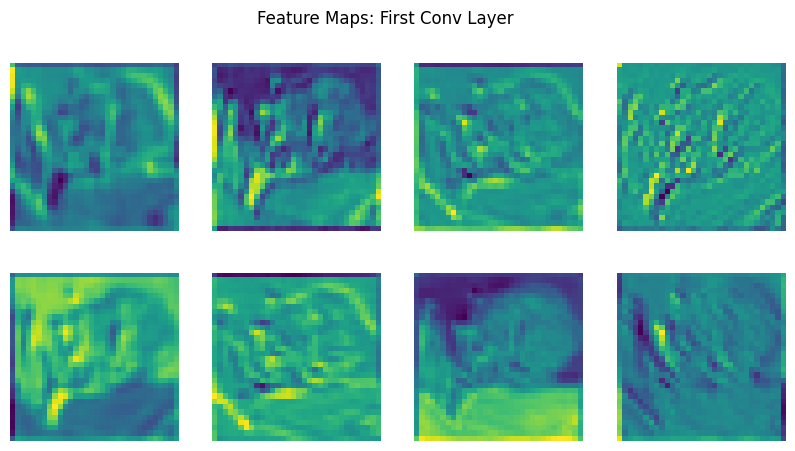

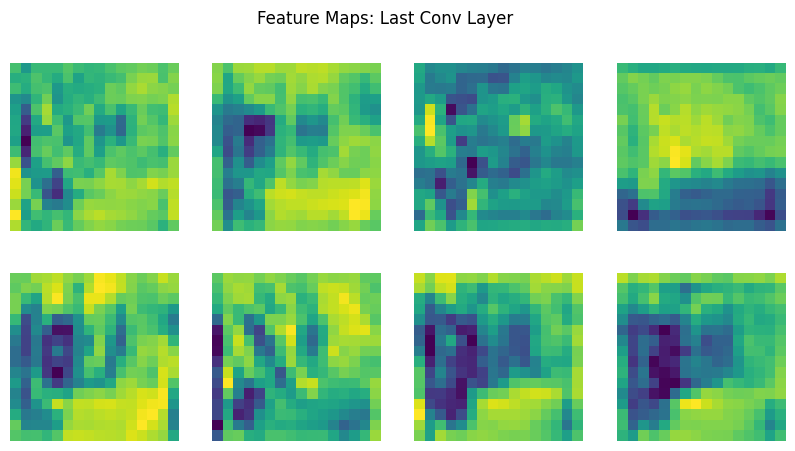

In [19]:
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. Select one correctly classified CIFAR-10 test image [cite: 219]
img_idx = 0
test_img = x_test_cifar[img_idx:img_idx+1]

# 2. Build a sub-model to extract activations [cite: 220]
# We find all layers that have 'conv' in their name
conv_layer_indices = [i for i, l in enumerate(best_cifar_model.layers) if 'conv' in l.name.lower()]
outputs = [best_cifar_model.layers[i].output for i in conv_layer_indices]
activation_model = tf.keras.models.Model(inputs=best_cifar_model.inputs, outputs=outputs)

# 3. Get activations for the test image
activations = activation_model.predict(test_img)

def plot_activations(layer_output, filename, title):
    plt.figure(figsize=(10, 5))
    for i in range(min(8, layer_output.shape[-1])): # Display first 8 feature maps [cite: 221]
        plt.subplot(2, 4, i+1)
        plt.imshow(layer_output[0, :, :, i], cmap='viridis')
        plt.axis('off')
    plt.suptitle(title)
    plt.savefig(filename) # Save as required [cite: 221, 222]
    plt.show()

# (a) First layer feature maps [cite: 221]
plot_activations(activations[0], 'fmaps_layer1.png', 'Feature Maps: First Conv Layer')

# (b) Last conv layer feature maps [cite: 222]
plot_activations(activations[-1], 'fmaps_last.png', 'Feature Maps: Last Conv Layer')

Comment on the visual difference between the two sets: what happens to spatial resolution, number of
channels, and visual interpretability as depth increases?

Spatial Resolution: Notice how the images in fmaps_layer1.png are large and clear, but in fmaps_last.png they are much smaller and "blocky".


Interpretability: Early layers show edges and colors that we recognize. Late layers show abstract patterns that represent complex shapes or objects which are harder for humans to "read"

Problem 3

In [29]:
# Standard CIFAR-10 class labels
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


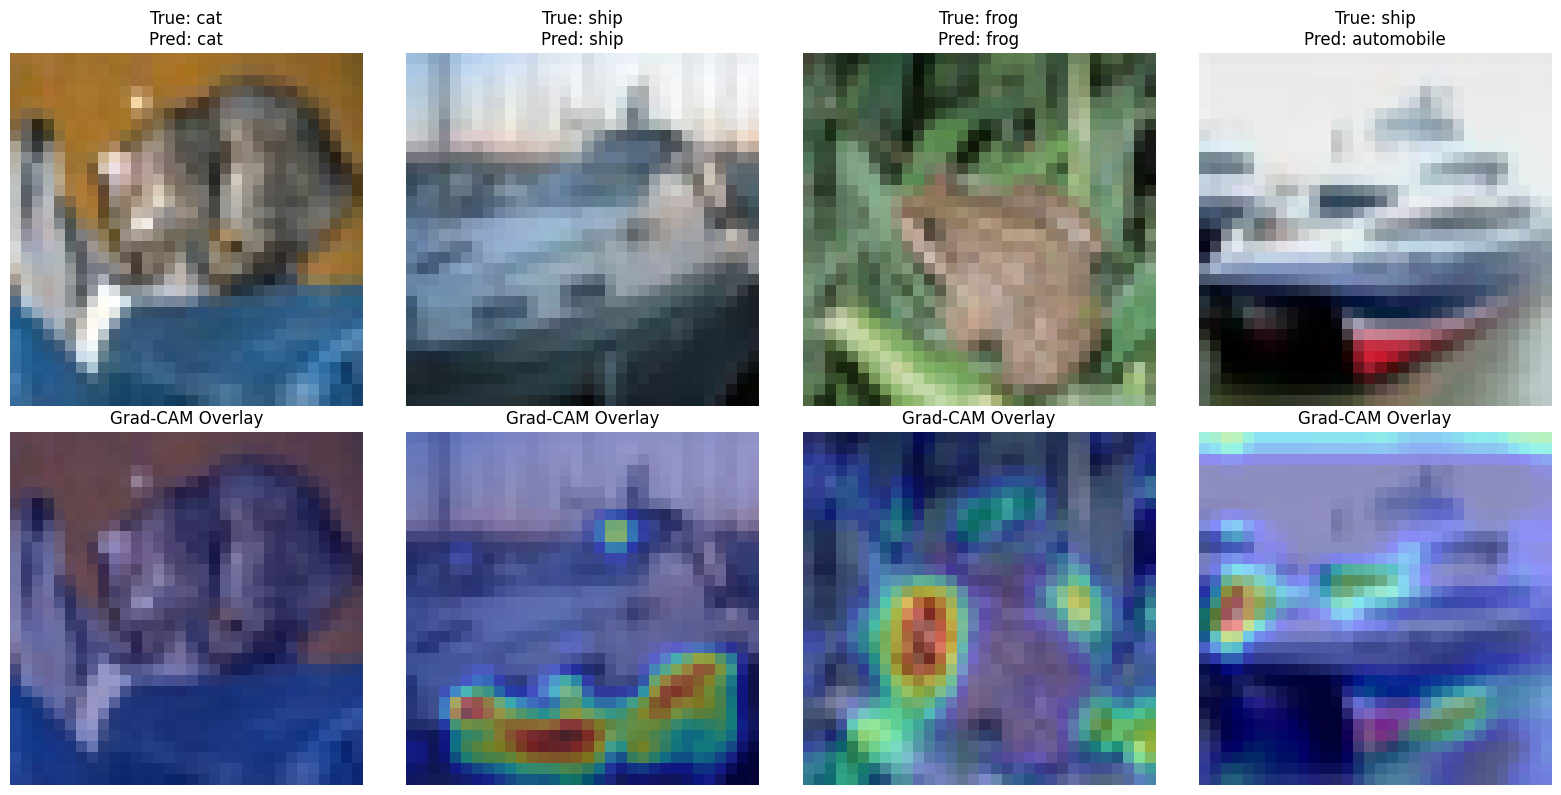

In [30]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def get_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # 1. We access the specific layer by name
    last_conv_layer = model.get_layer(last_conv_layer_name)

    # 2. To avoid the "never been called" error, we define a function
    # that computes both the layer output and the final model prediction
    def get_outputs(x):
        # We manually iterate through layers to extract the specific activation
        activation = x
        target_activation = None
        for layer in model.layers:
            activation = layer(activation)
            if layer.name == last_conv_layer_name:
                target_activation = activation
        return target_activation, activation

    # 3. Compute gradients using GradientTape (Problem 3a)
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = get_outputs(img_array)
        pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # Compute gradient of the top class with respect to the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # 4. Global-average-pool the gradients (Problem 3b)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 5. Multiply each channel in the feature map by its importance (Problem 3c)
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]

    # 6. Apply ReLU and Normalize (Problem 3c)
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

# Find 3 correctly classified and 1 misclassified image (Problem 3i, 3ii)
y_pred = best_cifar_model.predict(x_test_cifar)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_cifar, axis=1)

correct_indices = np.where(y_pred_classes == y_true_classes)[0][:3]
wrong_indices = np.where(y_pred_classes != y_true_classes)[0][:1]
indices_to_show = list(correct_indices) + list(wrong_indices)

# Plotting Loop
plt.figure(figsize=(16, 8))
TARGET_LAYER = 'conv2d_38' # Your specific layer name from previous error

for i, idx in enumerate(indices_to_show):
    img = x_test_cifar[idx:idx+1]
    heatmap = get_gradcam_heatmap(img, best_cifar_model, TARGET_LAYER)

    # Original Image
    plt.subplot(2, 4, i+1)
    plt.imshow(x_test_cifar[idx])
    plt.title(f"True: {class_names[y_true_classes[idx]]}\nPred: {class_names[y_pred_classes[idx]]}")
    plt.axis('off')

    # Grad-CAM Overlay (Problem 3d)
    plt.subplot(2, 4, i+5)
    plt.imshow(x_test_cifar[idx])
    # Resize heatmap to match image size (32, 32)
    resized_heatmap = tf.image.resize(heatmap[..., np.newaxis], (32, 32))[:,:,0]
    plt.imshow(resized_heatmap, cmap='jet', alpha=0.4)
    plt.title("Grad-CAM Overlay")
    plt.axis('off')

plt.tight_layout()
plt.savefig('gradcam_results.png') # Required filename
plt.show()

Problem 4

Classification Report:
              precision    recall  f1-score   support

    airplane       0.80      0.68      0.74      1000
  automobile       0.78      0.89      0.83      1000
        bird       0.72      0.45      0.55      1000
         cat       0.57      0.52      0.55      1000
        deer       0.64      0.69      0.66      1000
         dog       0.65      0.60      0.62      1000
        frog       0.77      0.81      0.79      1000
       horse       0.68      0.85      0.76      1000
        ship       0.72      0.89      0.80      1000
       truck       0.85      0.76      0.80      1000

    accuracy                           0.72     10000
   macro avg       0.72      0.72      0.71     10000
weighted avg       0.72      0.72      0.71     10000



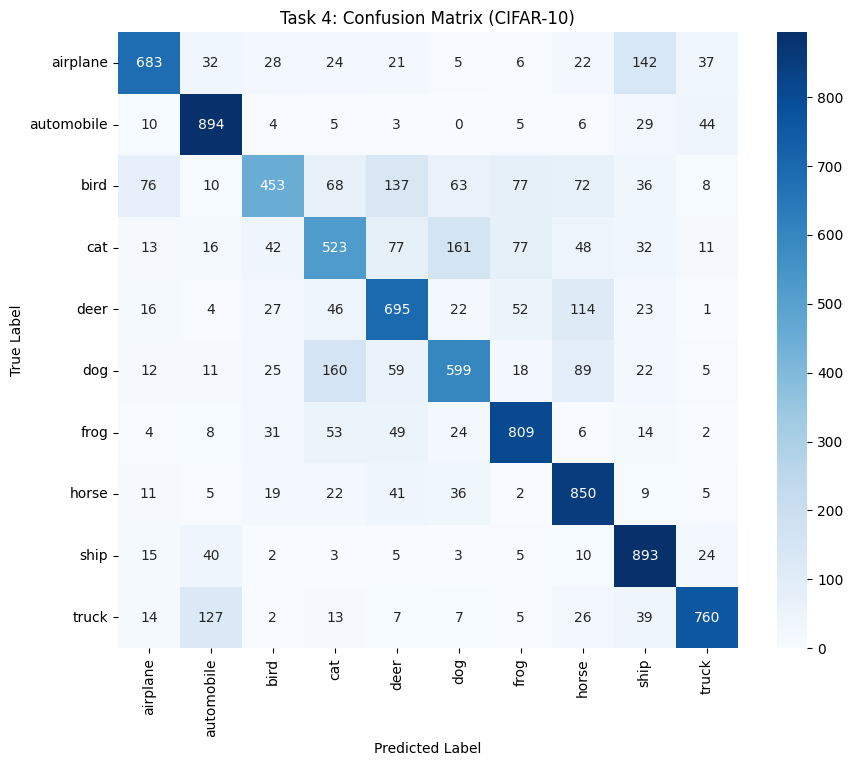

In [31]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Classification Report (Problem 4b)
print("Classification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

# Confusion Matrix (Problem 4a)
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.title('Task 4: Confusion Matrix (CIFAR-10)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('confusion_matrix.png')
plt.show()

**TASK 5**

Problem 1

In [32]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

print("--- Problem 1: Feature Extraction (Frozen Base) ---")

# 1. Load VGG16 without the top classification layers
base_model = tf.keras.applications.VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(96, 96, 3)
)

# 2. Freeze the base model so its pre-trained weights do not change
base_model.trainable = False

# 3. Build the Transfer Learning Model
tl_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.UpSampling2D(size=(3, 3)), # Upsamples CIFAR 32x32 -> 96x96
    base_model,
    layers.GlobalAveragePooling2D(),  # Flattens the output feature maps
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# 4. Compile the model
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Verify that only our new dense layers are trainable
print("Model Summary (Check Trainable Params):")
tl_model.summary()

# 5. Train the frozen model for 10 epochs
print("\nTraining Frozen Base...")
history_frozen = tl_model.fit(
    x_train_cifar, y_train_cifar,
    epochs=10,
    batch_size=64,
    validation_data=(x_test_cifar, y_test_cifar)
)

print("Problem 1 Training Complete.")

--- Problem 1: Feature Extraction (Frozen Base) ---
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Model Summary (Check Trainable Params):


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ up_sampling2d (UpSampling2D)    │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)


Training Frozen Base...
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 76s 88ms/step - accuracy: 0.5105 - loss: 1.3989 - val_accuracy: 0.6211 - val_loss: 1.0975
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 67s 85ms/step - accuracy: 0.6080 - loss: 1.1218 - val_accuracy: 0.6510 - val_loss: 0.9998
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 68s 87ms/step - accuracy: 0.6334 - loss: 1.0497 - val_accuracy: 0.6616 - val_loss: 0.9635
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 69s 89ms/step - accuracy: 0.6493 - loss: 1.0055 - val_accuracy: 0.6741 - val_loss: 0.9272
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 70s 90ms/step - accuracy: 0.6604 - loss: 0.9793 - val_accuracy: 0.6820 - val_loss: 0.9105
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 71s 91ms/step - accuracy: 0.6690 - loss: 0.9570 - val_accuracy: 0.6838 - val_loss: 0.8958
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 71s 91ms/step - accuracy: 0.6716 - loss: 0.9401 - val_accuracy: 0.6843 - val_loss: 0.8907
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 71s 91ms/step - accuracy:

Problem 2


--- Problem 2: Fine-Tuning Last 4 Layers ---
Model Summary for Fine-Tuning:


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ up_sampling2d (UpSampling2D)    │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 7,213,322 (27.52 MB)

 Non-trainable params: 7,635,264 (29.13 MB)


Fine-Tuning...
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 88s 106ms/step - accuracy: 0.7396 - loss: 0.7549 - val_accuracy: 0.7734 - val_loss: 0.6545
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 104ms/step - accuracy: 0.7972 - loss: 0.5837 - val_accuracy: 0.7960 - val_loss: 0.5932
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 106ms/step - accuracy: 0.8308 - loss: 0.4830 - val_accuracy: 0.8110 - val_loss: 0.5542
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 84s 108ms/step - accuracy: 0.8592 - loss: 0.4068 - val_accuracy: 0.8200 - val_loss: 0.5353
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 85s 108ms/step - accuracy: 0.8796 - loss: 0.3413 - val_accuracy: 0.8227 - val_loss: 0.5260
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 85s 109ms/step - accuracy: 0.8986 - loss: 0.2897 - val_accuracy: 0.8302 - val_loss: 0.5204
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 86s 109ms/step - accuracy: 0.9149 - loss: 0.2441 - val_accuracy: 0.8308 - val_loss: 0.5324
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 85s 109ms/step - accuracy: 

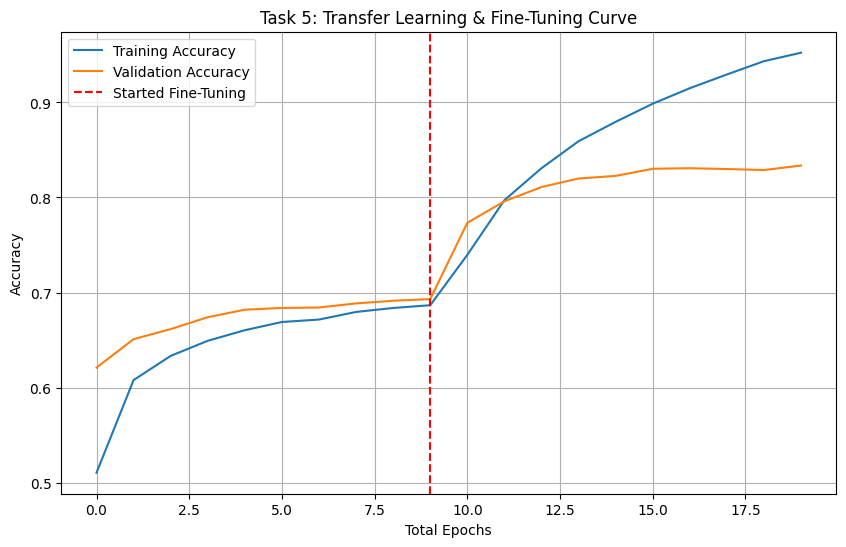

Problem 2 Complete. Graph Saved.


In [33]:
print("--- Problem 2: Fine-Tuning Last 4 Layers ---")

# 1. Unfreeze the entire base model
base_model.trainable = True

# 2. Re-freeze all layers EXCEPT the last 4
# This allows only the deepest convolutional layers to adapt to CIFAR-10
for layer in base_model.layers[:-4]:
    layer.trainable = False

# 3. Recompile the model! (Required whenever you change trainable status)
# IMPORTANT: Use a VERY small learning rate (1e-5)
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Verify trainable params have increased slightly
print("Model Summary for Fine-Tuning:")
tl_model.summary()

# 4. Continue training for another 10 epochs
print("\nFine-Tuning...")
history_finetune = tl_model.fit(
    x_train_cifar, y_train_cifar,
    epochs=10,
    batch_size=64,
    validation_data=(x_test_cifar, y_test_cifar)
)

# 5. Plot the complete training journey
acc = history_frozen.history['accuracy'] + history_finetune.history['accuracy']
val_acc = history_frozen.history['val_accuracy'] + history_finetune.history['val_accuracy']

plt.figure(figsize=(10, 6))
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(x=9, color='red', linestyle='--', label='Started Fine-Tuning') # Marks the transition at epoch 10
plt.title('Task 5: Transfer Learning & Fine-Tuning Curve')
plt.xlabel('Total Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('transfer_learning_results.png')
plt.show()

print("Problem 2 Complete. Graph Saved.")

Problem 3

--- Problem 3: Final Model Evaluation ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step

Transfer Learning Classification Report:
              precision    recall  f1-score   support

    airplane       0.87      0.91      0.89      1000
  automobile       0.92      0.91      0.92      1000
        bird       0.87      0.74      0.80      1000
         cat       0.67      0.65      0.66      1000
        deer       0.83      0.78      0.81      1000
         dog       0.67      0.79      0.72      1000
        frog       0.88      0.85      0.86      1000
       horse       0.83      0.90      0.87      1000
        ship       0.94      0.87      0.91      1000
       truck       0.89      0.93      0.91      1000

    accuracy                           0.83     10000
   macro avg       0.84      0.83      0.83     10000
weighted avg       0.84      0.83      0.83     10000



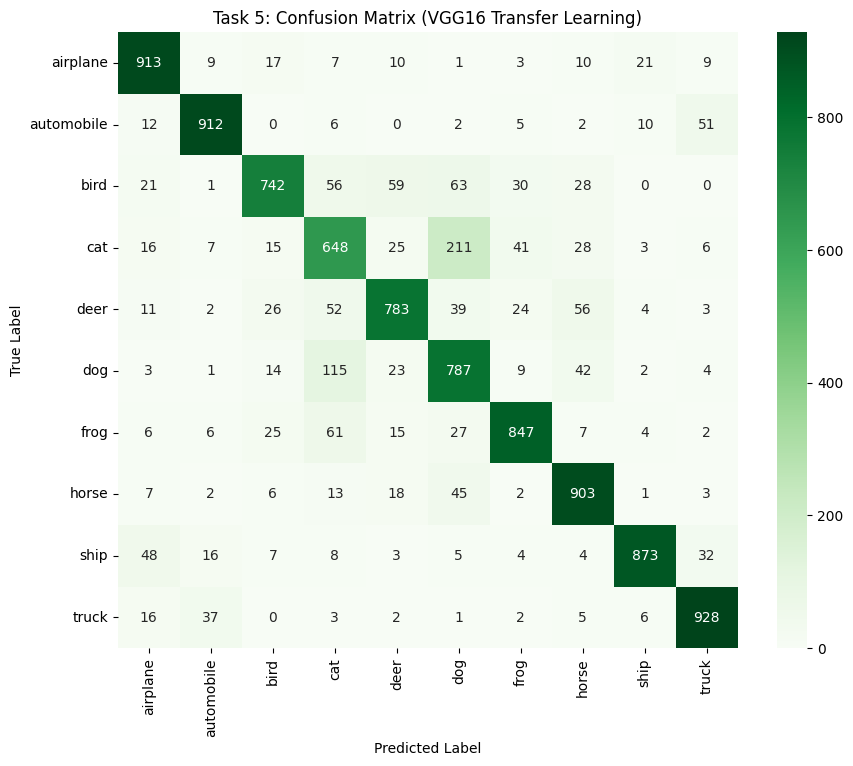

Custom CNN Accuracy: 0.7159
Transfer Learning Accuracy: 0.8336


In [34]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

print("--- Problem 3: Final Model Evaluation ---")

# 1. Get predictions for the test set
y_pred_tl = tl_model.predict(x_test_cifar)
y_pred_classes_tl = np.argmax(y_pred_tl, axis=1)
y_true_classes = np.argmax(y_test_cifar, axis=1)

# 2. Print Classification Report
print("\nTransfer Learning Classification Report:")
print(classification_report(y_true_classes, y_pred_classes_tl, target_names=class_names))

# 3. Plot Confusion Matrix
cm_tl = confusion_matrix(y_true_classes, y_pred_classes_tl)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_tl, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Greens')
plt.title('Task 5: Confusion Matrix (VGG16 Transfer Learning)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('tl_confusion_matrix.png')
plt.show()

# 4. Compare with Task 4 model
# (Note: This assumes 'best_cifar_model' from Task 4 is still in memory)
test_loss_custom, test_acc_custom = best_cifar_model.evaluate(x_test_cifar, y_test_cifar, verbose=0)
test_loss_tl, test_acc_tl = tl_model.evaluate(x_test_cifar, y_test_cifar, verbose=0)

print(f"Custom CNN Accuracy: {test_acc_custom:.4f}")
print(f"Transfer Learning Accuracy: {test_acc_tl:.4f}")